# Random Forest — Ad-hoc Genre Consolidation + Grid Search + Centrality Ablation

Lighter pipeline than nb21/nb31. No CV SHAP, no forward selection.

| Step | Description |
|:----:|-------------|
| 1 | Ad-hoc genre consolidation — keep 8 genres, fold rest into `other` |
| 2 | Grid search (54 combinations) on consolidated features |
| 3 | Centrality ablation (2³ = 8 subsets) with winning params |
| 4 | Final fit + OOF threshold tuning + diagnostics |

In [1]:
import warnings
warnings.filterwarnings('ignore')

import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score, brier_score_loss, log_loss,
    precision_score, recall_score, f1_score,
    RocCurveDisplay, precision_recall_curve
)
from sklearn.model_selection import train_test_split, StratifiedKFold

import shap

In [2]:
RANDOM_STATE = 42
N_SPLITS     = 5
LAM          = 0.3   # penalized score = CV AUC - LAM * gap

# Genres kept as individual features; all others → artist_genre_other
KEEP_GENRES = [
    'R&B/Soul/Funk', 'Hip Hop/Rap', 'Latin', 'Electronic/Dance',
    'Folk', 'Pop', 'Country/Americana', 'Rock',
]

CENTRALITY_FEATS = [
    'betweenness_centrality_top20_rolling5',
    'eigenvector_centrality_top20_rolling5',
    'harmonic_closeness_centrality_top20_rolling5',
]

# Grid search — n_estimators fixed after winning value found
PARAM_GRID = [
    {'n_estimators': n, 'max_depth': d, 'min_samples_leaf': l, 'max_features': f,
     'class_weight': 'balanced', 'random_state': RANDOM_STATE, 'n_jobs': -1}
    for n, d, l, f in itertools.product([100, 300, 500], [3, 5, 8], [1, 5, 10], ['sqrt', 0.5])
]

# Reference AUCs
NB21_RF_AUC  = 0.7671
NB29_RF_MEAN = 0.7602

df = pd.read_csv('../df_artists_final.csv', index_col=0).reset_index()
X  = df.drop(columns=['top_20_hitmaker'])
y  = df['top_20_hitmaker']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

print(f'Train: {X_train.shape}  Test: {X_test.shape}')
print(f'Class balance (train): {y_train.mean():.3f} hitmaker')
print(f'Grid size: {len(PARAM_GRID)} combinations')

Train: (607, 26)  Test: (152, 26)
Class balance (train): 0.432 hitmaker
Grid size: 54 combinations


## Step 1 — Ad-hoc Genre Consolidation

Keep 8 genres with above-average or near-average hitmaker rates as individual features.
All remaining genres folded into `artist_genre_other`.

In [3]:
def consolidate_genres(X, keep_genres):
    X = X.copy()
    keep_cols  = [f'artist_genre_{g}' for g in keep_genres]
    all_genre_cols = [c for c in X.columns if c.startswith('artist_genre_')]
    drop_cols  = [c for c in all_genre_cols if c not in keep_cols]

    X['artist_genre_other'] = X[drop_cols].max(axis=1)
    X = X.drop(columns=drop_cols)
    return X

imp = SimpleImputer(strategy='median')
X_train_imp = pd.DataFrame(imp.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_imp  = pd.DataFrame(imp.transform(X_test),      columns=X_test.columns,  index=X_test.index)

X_train_c = consolidate_genres(X_train_imp, KEEP_GENRES)
X_test_c  = consolidate_genres(X_test_imp,  KEEP_GENRES)

genre_cols_before = [c for c in X_train_imp.columns if c.startswith('artist_genre_')]
genre_cols_after  = [c for c in X_train_c.columns   if c.startswith('artist_genre_')]
print(f'Features before: {X_train_imp.shape[1]}  →  after: {X_train_c.shape[1]}')
print(f'Genres before  : {len(genre_cols_before)}  →  after: {len(genre_cols_after)}')
print(f'Kept genres    : {[c.replace("artist_genre_","") for c in genre_cols_after if c != "artist_genre_other"]}')

Features before: 26  →  after: 16
Genres before  : 19  →  after: 9
Kept genres    : ['Country/Americana', 'Electronic/Dance', 'Folk', 'Hip Hop/Rap', 'Latin', 'Pop', 'R&B/Soul/Funk', 'Rock']


## Step 2 — Grid Search

54 combinations: `n_estimators` ∈ {100, 300, 500} × `max_depth` ∈ {3, 5, 8} × `min_samples_leaf` ∈ {1, 5, 10} × `max_features` ∈ {'sqrt', 0.5}.  
Winner selected by penalized CV AUC = AUC − λ × gap.

In [4]:
def cv_evaluate(X, y, params, skf):
    cv_aucs, tr_aucs = [], []
    for tr, va in skf.split(X, y):
        X_tr, X_va = X.iloc[tr], X.iloc[va]
        y_tr, y_va = y.iloc[tr], y.iloc[va]
        m = RandomForestClassifier(**params)
        m.fit(X_tr, y_tr)
        cv_aucs.append(roc_auc_score(y_va, m.predict_proba(X_va)[:, 1]))
        tr_aucs.append(roc_auc_score(y_tr, m.predict_proba(X_tr)[:, 1]))
    cv  = np.mean(cv_aucs)
    tr  = np.mean(tr_aucs)
    gap = tr - cv
    return {'CV AUC': cv, 'Train AUC': tr, 'Gap': gap, 'Penalized': cv - LAM * gap}


def grid_search_rf(X, y, skf):
    best_params, best_score = None, -np.inf
    for params in PARAM_GRID:
        res = cv_evaluate(X, y, params, skf)
        if res['Penalized'] > best_score:
            best_score, best_params = res['Penalized'], params
    return best_params, best_score

In [5]:
print(f'Grid search ({len(PARAM_GRID)} combinations)...')
best_params, _ = grid_search_rf(X_train_c, y_train, skf)

res_grid = cv_evaluate(X_train_c, y_train, best_params, skf)
print(f'  Best params : {best_params}')
print(f'  CV AUC      : {res_grid["CV AUC"]:.4f}')
print(f'  Train AUC   : {res_grid["Train AUC"]:.4f}')
print(f'  Gap         : {res_grid["Gap"]:.4f}')
print(f'  Penalized   : {res_grid["Penalized"]:.4f}')

# Fix n_estimators from grid winner for ablation and final fit
FIXED_N_EST = best_params['n_estimators']
print(f'\nn_estimators fixed at {FIXED_N_EST} for ablation and final fit')

Grid search (54 combinations)...
  Best params : {'n_estimators': 500, 'max_depth': 3, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'class_weight': 'balanced', 'random_state': 42, 'n_jobs': -1}
  CV AUC      : 0.7575
  Train AUC   : 0.8110
  Gap         : 0.0536
  Penalized   : 0.7414

n_estimators fixed at 500 for ablation and final fit


## Step 3 — Centrality Ablation

Test all 2³ = 8 subsets of centrality features using winning params.  
Keep the subset that maximizes CV AUC.

In [6]:
# Fix n_estimators to winner, re-use other best params
ablation_params = {**best_params, 'n_estimators': FIXED_N_EST}

non_centrality = [c for c in X_train_c.columns if c not in CENTRALITY_FEATS]

best_subset, best_cv, best_combo = None, -np.inf, None
rows = []

for k in range(len(CENTRALITY_FEATS) + 1):
    for combo in itertools.combinations(CENTRALITY_FEATS, k):
        feats = non_centrality + list(combo)
        res   = cv_evaluate(X_train_c[feats], y_train, ablation_params, skf)
        rows.append({'Centrality kept': list(combo) or ['none'], 'CV AUC': res['CV AUC'], 'Gap': res['Gap']})
        if res['CV AUC'] > best_cv:
            best_cv, best_subset, best_combo = res['CV AUC'], feats, list(combo)

df_abl = pd.DataFrame(rows).sort_values('CV AUC', ascending=False)
print(df_abl.to_string(index=False))
print(f'\nBest centrality subset : {best_combo if best_combo else "none"}')
print(f'Best CV AUC            : {best_cv:.4f}')
print(f'Final feature set      : n={len(best_subset)}')

                                                                                                             Centrality kept   CV AUC      Gap
                                                                              [harmonic_closeness_centrality_top20_rolling5] 0.759654 0.043871
                                                                                     [betweenness_centrality_top20_rolling5] 0.758396 0.046245
                                       [betweenness_centrality_top20_rolling5, harmonic_closeness_centrality_top20_rolling5] 0.758196 0.048557
                                                                                     [eigenvector_centrality_top20_rolling5] 0.757031 0.044669
[betweenness_centrality_top20_rolling5, eigenvector_centrality_top20_rolling5, harmonic_closeness_centrality_top20_rolling5] 0.756424 0.053978
                                              [betweenness_centrality_top20_rolling5, eigenvector_centrality_top20_rolling5] 0.756206 0.048696

## Step 4 — Final Fit + OOF Threshold Tuning

In [7]:
feats_final  = best_subset
params_final = {**best_params, 'n_estimators': FIXED_N_EST}

X_tr_f = X_train_c[feats_final]
X_te_f = X_test_c[feats_final]

# OOF threshold tuning
oof_proba = np.zeros(len(y_train))
for tr, va in skf.split(X_tr_f, y_train):
    m = RandomForestClassifier(**params_final)
    m.fit(X_tr_f.iloc[tr], y_train.iloc[tr])
    oof_proba[va] = m.predict_proba(X_tr_f.iloc[va])[:, 1]

thresholds = np.linspace(0.05, 0.95, 181)
best_t, best_f1 = 0.5, 0.0
for t in thresholds:
    f1 = f1_score(y_train, (oof_proba >= t).astype(int), zero_division=0)
    if f1 > best_f1:
        best_f1, best_t = f1, t

# Final model on full training set
model_final = RandomForestClassifier(**params_final)
model_final.fit(X_tr_f, y_train)

train_proba = model_final.predict_proba(X_tr_f)[:, 1]
test_proba  = model_final.predict_proba(X_te_f)[:, 1]
train_auc   = roc_auc_score(y_train, train_proba)
test_auc    = roc_auc_score(y_test,  test_proba)

y_pred_05 = (test_proba >= 0.50).astype(int)
y_pred_t  = (test_proba >= best_t).astype(int)

print(f'Test AUC  : {test_auc:.4f}')
print(f'Train AUC : {train_auc:.4f}')
print(f'Gap       : {train_auc - test_auc:.4f}')
print(f'Logloss   : {log_loss(y_test, test_proba):.4f}')
print(f'Brier     : {brier_score_loss(y_test, test_proba):.4f}')
print(f'\nThreshold=0.50  P={precision_score(y_test, y_pred_05, zero_division=0):.3f}  R={recall_score(y_test, y_pred_05):.3f}  F1={f1_score(y_test, y_pred_05):.3f}')
print(f'Threshold={best_t:.2f}  P={precision_score(y_test, y_pred_t, zero_division=0):.3f}  R={recall_score(y_test, y_pred_t):.3f}  F1={f1_score(y_test, y_pred_t):.3f}')

Test AUC  : 0.7662
Train AUC : 0.7982
Gap       : 0.0320
Logloss   : 0.5867
Brier     : 0.2008

Threshold=0.50  P=0.587  R=0.667  F1=0.624
Threshold=0.46  P=0.559  R=0.788  F1=0.654


## Diagnostics

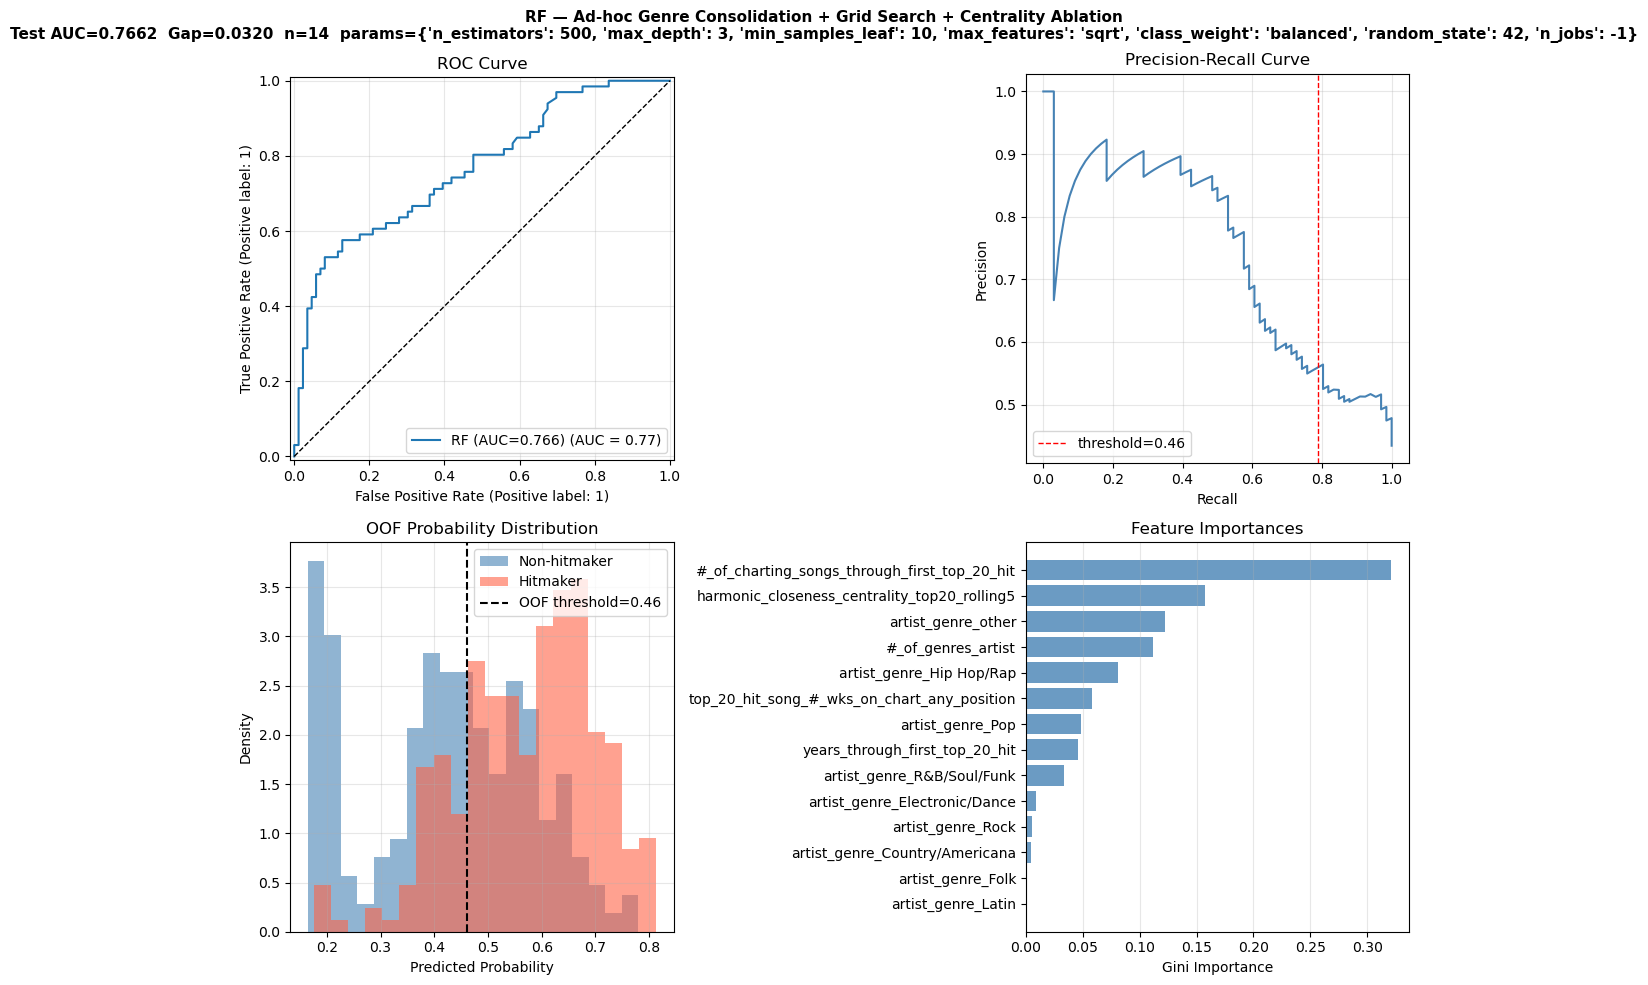

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle(
    f'RF — Ad-hoc Genre Consolidation + Grid Search + Centrality Ablation\n'
    f'Test AUC={test_auc:.4f}  Gap={train_auc - test_auc:.4f}  n={len(feats_final)}  params={params_final}',
    fontsize=11, fontweight='bold'
)

# ROC curve
RocCurveDisplay.from_predictions(y_test, test_proba, ax=axes[0, 0], name=f'RF (AUC={test_auc:.3f})')
axes[0, 0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0, 0].set_title('ROC Curve')
axes[0, 0].grid(True, alpha=0.3)

# Precision-Recall curve
prec, rec, thr = precision_recall_curve(y_test, test_proba)
axes[0, 1].plot(rec, prec, color='steelblue')
axes[0, 1].axvline(recall_score(y_test, y_pred_t), color='red', lw=1, linestyle='--',
                   label=f'threshold={best_t:.2f}')
axes[0, 1].set_xlabel('Recall'); axes[0, 1].set_ylabel('Precision')
axes[0, 1].set_title('Precision-Recall Curve')
axes[0, 1].legend(); axes[0, 1].grid(True, alpha=0.3)

# OOF predicted probability distribution
axes[1, 0].hist(oof_proba[y_train == 0], bins=20, alpha=0.6, color='steelblue', label='Non-hitmaker', density=True)
axes[1, 0].hist(oof_proba[y_train == 1], bins=20, alpha=0.6, color='tomato',    label='Hitmaker',     density=True)
axes[1, 0].axvline(best_t, color='black', lw=1.5, linestyle='--', label=f'OOF threshold={best_t:.2f}')
axes[1, 0].set_xlabel('Predicted Probability'); axes[1, 0].set_ylabel('Density')
axes[1, 0].set_title('OOF Probability Distribution')
axes[1, 0].legend(); axes[1, 0].grid(True, alpha=0.3)

# Feature importances
importances = pd.Series(model_final.feature_importances_, index=feats_final).sort_values(ascending=True)
axes[1, 1].barh(importances.index, importances.values, color='steelblue', alpha=0.8)
axes[1, 1].set_xlabel('Gini Importance'); axes[1, 1].set_title('Feature Importances')
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('rf_adhoc_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

## SHAP Feature Importance

In [ ]:
explainer   = shap.TreeExplainer(model_final)
shap_values = explainer.shap_values(X_te_f)

if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values

shap_mean = pd.Series(np.abs(sv).mean(axis=0), index=feats_final).sort_values(ascending=False)
print('Top features by mean |SHAP|:')
print(shap_mean.to_string())

fig, ax = plt.subplots(figsize=(8, 0.4 * len(feats_final) + 1))
shap_mean.sort_values().plot.barh(ax=ax, color='steelblue', alpha=0.8)
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('SHAP Feature Importance — Test Set')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('rf_adhoc_shap.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary

In [ ]:
print('=' * 60)
print('  Random Forest — Final Results (nb32)')
print('=' * 60)
print(f'  N features  : {len(feats_final)}')
print(f'  Best params : {params_final}')
print(f'  Centrality  : {best_combo if best_combo else "none kept"}')
print(f'  λ           : {LAM}')
print()
print(f'  Train AUC : {train_auc:.4f}')
print(f'  Test AUC  : {test_auc:.4f}')
print(f'  Gap       : {train_auc - test_auc:.4f}')
print(f'  Logloss   : {log_loss(y_test, test_proba):.4f}')
print(f'  Brier     : {brier_score_loss(y_test, test_proba):.4f}')
print()
print(f'  Threshold=0.50  P={precision_score(y_test, y_pred_05, zero_division=0):.3f}  R={recall_score(y_test, y_pred_05):.3f}  F1={f1_score(y_test, y_pred_05):.3f}')
print(f'  Threshold={best_t:.2f}  P={precision_score(y_test, y_pred_t, zero_division=0):.3f}  R={recall_score(y_test, y_pred_t):.3f}  F1={f1_score(y_test, y_pred_t):.3f}')
print()
print(f'  nb21 RF reference  →  Test AUC={NB21_RF_AUC:.4f}  Gap=0.005  N=9')
print(f'  nb29 fixed-param   →  Test AUC mean={NB29_RF_MEAN:.4f}  (B=100)')